In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
import os
import pandas as pd

base_dir = "AugmentedAlzheimerDataset"

MildDemented_dir = os.path.join(base_dir, "MildDemented")
ModerateDemented_dir = os.path.join(base_dir, "ModerateDemented")
NonDemented_dir = os.path.join(base_dir, "NonDemented")
VeryMildDemented_dir = os.path.join(base_dir, "VeryMildDemented")

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths         labels
0  AugmentedAlzheimerDataset\MildDemented\00046ff...  Mild Demented
1  AugmentedAlzheimerDataset\MildDemented\000cdcc...  Mild Demented
2  AugmentedAlzheimerDataset\MildDemented\0013ad5...  Mild Demented
3  AugmentedAlzheimerDataset\MildDemented\0015bdf...  Mild Demented
4  AugmentedAlzheimerDataset\MildDemented\001f15e...  Mild Demented
labels
Non Demented         9600
Mild Demented        8960
Very MildDemented    8960
Moderate Demented    6464
Name: count, dtype: int64


In [3]:
train_dummy, test_images = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)
train_set, val_set = train_test_split(train_dummy, test_size=0.2, random_state=42)
image_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

test = image_gen.flow_from_dataframe(
    dataframe=test_images, 
    x_col="filepaths", 
    y_col="labels",
    target_size=(244,244), 
    color_mode='rgb',
    class_mode="categorical",
    batch_size=32,
    shuffle=False 
)

y_test = test.labels 
class_labels = list(test.class_indices.keys())

Found 6797 validated image filenames belonging to 4 classes.


In [4]:
modelo_original = tf.keras.models.load_model("Alzheimer_Model.h5")
modelo_optimizado = tf.keras.models.load_model("Alzheimer_Model_Optimized.h5")

In [5]:
print("========================================")
print(" RENDIMIENTO: MODELO ORIGINAL")
print("========================================")
modelo_original.evaluate(test, verbose=1)

print("\n========================================")
print(" RENDIMIENTO: MODELO OPTIMIZADO")
print("========================================")
modelo_optimizado.evaluate(test, verbose=1)

 RENDIMIENTO: MODELO ORIGINAL
213/213 [==============================] - 13s 36ms/step - loss: 0.4106 - accuracy: 0.8861

 RENDIMIENTO: MODELO OPTIMIZADO
213/213 [==============================] - 7s 30ms/step - loss: 0.0900 - accuracy: 0.9723


[0.08998493105173111, 0.9723407626152039]

213/213 [==============================] - 7s 32ms/step
--- REPORTE: MODELO ORIGINAL ---
                   precision    recall  f1-score   support

    Mild Demented       0.88      0.91      0.90      1793
Moderate Demented       0.99      0.99      0.99      1314
     Non Demented       0.91      0.82      0.86      1878
Very MildDemented       0.79      0.85      0.82      1812

         accuracy                           0.89      6797
        macro avg       0.90      0.89      0.89      6797
     weighted avg       0.89      0.89      0.89      6797

Precisión Global: 88.61%


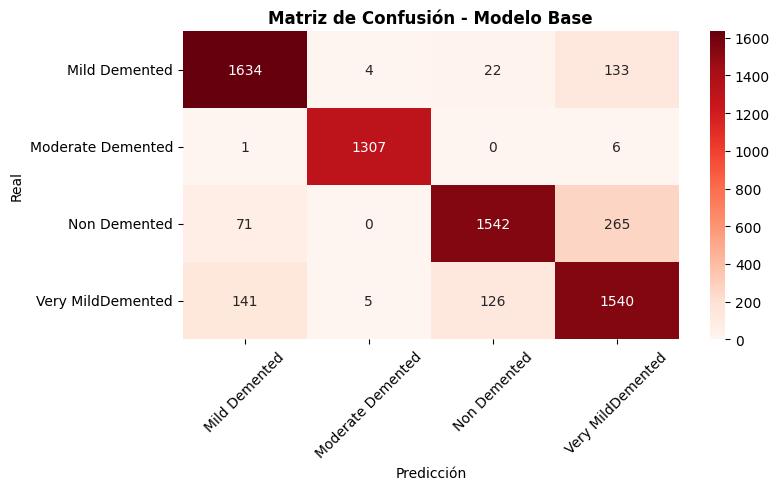

In [6]:
pred_orig = modelo_original.predict(test)
pred_orig_classes = np.argmax(pred_orig, axis=1)

print("--- REPORTE: MODELO ORIGINAL ---")
print(classification_report(y_test, pred_orig_classes, target_names=class_labels))
print("Precisión Global:", "{:.2f}%".format(accuracy_score(y_test, pred_orig_classes)*100))

cm_orig = confusion_matrix(y_test, pred_orig_classes)
plt.figure(figsize=(8, 4))
sns.heatmap(cm_orig, annot=True, fmt='g', vmin=0, cmap='Reds')
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=45)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=0)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Base", fontweight='bold')
plt.savefig('matriz_confusion_base.png', dpi=300, bbox_inches='tight')
plt.show()

213/213 [==============================] - 7s 32ms/step
--- REPORTE: MODELO OPTIMIZADO ---
                   precision    recall  f1-score   support

    Mild Demented       0.97      1.00      0.98      1793
Moderate Demented       1.00      1.00      1.00      1314
     Non Demented       0.97      0.95      0.96      1878
Very MildDemented       0.95      0.96      0.95      1812

         accuracy                           0.97      6797
        macro avg       0.97      0.97      0.97      6797
     weighted avg       0.97      0.97      0.97      6797

Precisión Global: 97.23%


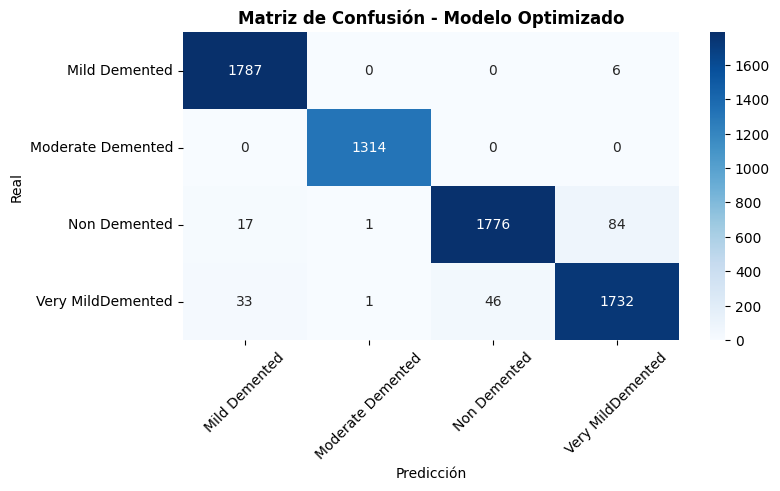

In [7]:
pred_opt = modelo_optimizado.predict(test)
pred_opt_classes = np.argmax(pred_opt, axis=1)

print("--- REPORTE: MODELO OPTIMIZADO ---")
print(classification_report(y_test, pred_opt_classes, target_names=class_labels))
print("Precisión Global:", "{:.2f}%".format(accuracy_score(y_test, pred_opt_classes)*100))

cm_opt = confusion_matrix(y_test, pred_opt_classes)
plt.figure(figsize=(8, 4))
sns.heatmap(cm_opt, annot=True, fmt='g', vmin=0, cmap='Blues')
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=45)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels, rotation=0)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Optimizado", fontweight='bold')
plt.savefig('matriz_confusion_optimizado.png', dpi=300, bbox_inches='tight')
plt.show()